In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

import joblib

In [4]:
stores = pd.read_csv("/content/dim_stores.csv")

skus = pd.read_csv("/content/dim_skus.csv")

suppliers = pd.read_csv("/content/dim_suppliers.csv")

events = pd.read_csv("/content/dim_events.csv")

inventory = pd.read_csv("/content/fact_inventory_daily.csv")

In [5]:
inventory["date"] = pd.to_datetime(inventory["date"])
events["date"] = pd.to_datetime(events["date"])

In [6]:
print("Stores:", stores.shape)
print("SKUs:", skus.shape)
print("Suppliers:", suppliers.shape)
print("Events:", events.shape)
print("Inventory:", inventory.shape)


Stores: (12, 8)
SKUs: (60, 9)
Suppliers: (15, 6)
Events: (30, 5)
Inventory: (21600, 16)


In [7]:
inventory["stockout_risk"].value_counts()

,count
stockout_risk,
Safe,14131
At-Risk,5186
Imminent,2283


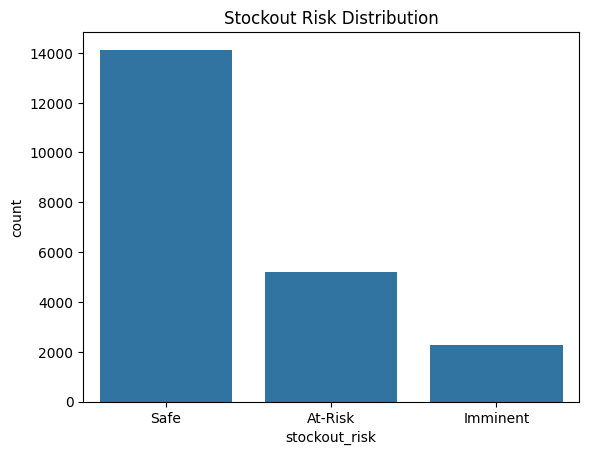

In [8]:
sns.countplot(data=inventory, x="stockout_risk")
plt.title("Stockout Risk Distribution")
plt.show()

In [9]:
print(inventory["date"].min())
print(inventory["date"].max())
print(inventory["date"].nunique())

2026-10-01 00:00:00
2026-10-30 00:00:00
30


In [10]:
events[events["event_name"] == "Diwali Week"]

,date,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
21,2026-10-22,Diwali Week,festival,1.4,1.100
22,2026-10-23,Diwali Week,festival,1.7,1.175
23,2026-10-24,Diwali Week,festival,2.1,1.275
24,2026-10-25,Diwali Week,festival,2.6,1.400
25,2026-10-26,Diwali Week,festival,1.9,1.225


In [11]:
events[events["date"] == "2026-10-25"]

,date,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
24,2026-10-25,Diwali Week,festival,2.6,1.4


In [12]:
events[events["date"] == "2026-10-11"]

,date,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
10,2026-10-11,Weekend Flash Sale,promo,1.3,1.3


In [13]:
inventory.isnull().sum()

,0
date,0
store_id,0
sku_id,0
supplier_id,0
opening_stock,0
units_demanded,0
units_sold,0
closing_stock,0
reorder_point,0
reorder_placed,0


In [14]:
stores[stores["city"] != stores["city_display"]]

,store_id,city,city_display,city_tier,store_size,sqft,opened_year,baseline_daily_orders
2,ST03,Bengaluru,BENGALURU,Tier1,Large,3650,2022,552
8,ST09,Hyderabad,hyderabad,Tier1,Small,1445,2024,239


In [15]:
stores["city_display"] = stores["city_display"].str.title()

In [16]:
suppliers[suppliers["reliability_score"].isna()]

,supplier_id,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days
5,SUP06,QuickBev Distributors,"Personal Care, Home Care",NaN,1,2.2
13,SUP14,Prime Personal Care,Staples,NaN,4,1.9
14,SUP15,Regional Produce Hub,Beverages,NaN,5,2.1


In [18]:
suppliers = pd.read_csv(
    "/content/dim_suppliers.csv",
    na_values=["N/A", "missing", "--", "NA", "null"],
    keep_default_na=True
)

In [22]:
#Festival effect
festival_rate = (
    inventory[inventory["is_festival_week"] == "Y"]["stockout_risk"]
    .eq("Imminent")
    .mean()
)

nonfestival_rate = (
    inventory[inventory["is_festival_week"] == "N"]["stockout_risk"]
    .eq("Imminent")
    .mean()
)

print(nonfestival_rate)
print(festival_rate)

0.09511632571199358
0.23309178743961353


In [21]:
#perishable effect
temp = inventory.merge(
    skus[["sku_id", "is_perishable"]],
    on="sku_id",
    how="left"
)

In [23]:
temp.groupby("is_perishable")["stockout_risk"].apply(
    lambda x: (x == "Imminent").mean()
)

,stockout_risk
is_perishable,
N,0.092982
Y,0.127652


In [24]:
#Supplier reliability effect
temp = inventory.merge(
    suppliers[["supplier_id", "reliability_score"]],
    on="supplier_id",
    how="left"
)

In [25]:
#four dimension tables
df = inventory.copy()

In [26]:
df = df.merge(
    stores,
    on="store_id",
    how="left"
)

In [29]:
#Join SKUs:
df = df.merge(
    skus,
    on="sku_id",
    how="left"
)

In [30]:
#Join suppliers:
df = df.merge(
    suppliers,
    on="supplier_id",
    how="left"
)

In [31]:
#Join events:
df = df.merge(
    events,
    on="date",
    how="left"
)

In [32]:
print(df.shape)

(21600, 48)


In [33]:
print(df["store_id"].isna().sum())
print(df["sku_id"].isna().sum())
print(df["supplier_id"].isna().sum())
print(df["event_name"].isna().sum())

0
0
0
0


Feature engineering

In [34]:
#Feature 1 — Reorder gap
df["reorder_gap"] = (
    df["reorder_point"] - df["closing_stock"]
)

In [35]:
#Feature 2 — Days of cover ratio
df["days_of_cover_ratio"] = (
    df["days_of_cover"] /
    df["lead_time_days_expected"]
)

In [36]:
#Feature 3 — Clean supplier reliability
df["supplier_reliability_clean"] = pd.to_numeric(
    df["reliability_score"],
    errors="coerce"
)

In [37]:
median_reliability = df["supplier_reliability_clean"].median()

df["supplier_reliability_clean"] = (
    df["supplier_reliability_clean"]
    .fillna(median_reliability)
)

In [38]:
#Feature 4 — Recent reorder
df = df.sort_values(
    ["store_id", "sku_id", "date"]
)

In [39]:
reorder_flag = (
    df["reorder_placed"] == "Y"
).astype(int)

In [40]:
df["is_recent_reorder"] = (
    reorder_flag
    .groupby([df["store_id"], df["sku_id"]])
    .transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).max()
    )
    .fillna(0)
    .astype(int)
)

In [42]:
#Feature 5 — Day of month
df["day_of_month"] = df["date"].dt.day

In [43]:
#Feature 6 — Days since festival start
#Since Diwali week begins October 22:

df["days_since_festival_start"] = np.where(
    df["date"].dt.day >= 22,
    df["date"].dt.day - 22,
    -1
)

In [46]:
feature_columns = [
    # Inventory / demand
    "opening_stock",
    "units_demanded",
    "units_sold",
    "closing_stock",
    "reorder_point",
    "sales_velocity_7d",
    "days_of_cover",

    # Lead time
    "lead_time_days_expected",
    "base_lead_time_days",
    "lead_time_variance_days",

    # Supplier
    "supplier_reliability_clean",

    # Product
    "unit_price_inr",
    "shelf_life_days",

    # Store
    "sqft",
    "baseline_daily_orders",

    # Engineered features
    "reorder_gap",
    "days_of_cover_ratio",
    "is_recent_reorder",
    "day_of_month",
    "days_since_festival_start",

    # Event / demand
    "demand_multiplier_festive",
    "demand_multiplier_other",

    # Categorical features
    "city",
    "store_size",
    "category",
    "is_perishable",
    "festive_relevant",
    "popularity_tier",
    "event_type",
    "reorder_placed",
    "is_festival_week"
]

In [47]:
missing_features = [
    col for col in feature_columns
    if col not in df.columns
]

print("Missing features:", missing_features)

Missing features: ['unit_price_inr', 'shelf_life_days', 'category', 'is_perishable', 'festive_relevant', 'popularity_tier']


In [50]:
print("Current df columns:")
print(df.columns.tolist())

Current df columns:
['date', 'store_id', 'sku_id', 'supplier_id_x', 'opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'is_festival_week', 'stockout_risk', 'city', 'city_display', 'city_tier', 'store_size', 'sqft', 'opened_year', 'baseline_daily_orders', 'sku_name_x', 'category_x', 'unit_price_inr_x', 'shelf_life_days_x', 'is_perishable_x', 'festive_relevant_x', 'popularity_tier_x', 'supplier_id_y', 'sku_name_y', 'category_y', 'unit_price_inr_y', 'shelf_life_days_y', 'is_perishable_y', 'festive_relevant_y', 'popularity_tier_y', 'supplier_id', 'supplier_name', 'categories_supplied', 'reliability_score', 'base_lead_time_days', 'lead_time_variance_days', 'event_name', 'event_type', 'demand_multiplier_festive', 'demand_multiplier_other', 'reorder_gap', 'days_of_cover_ratio', 'supplier_reliability_clean', 'is_recent_reorder', 'day_of_month', 'days_since

In [53]:
print("INVENTORY COLUMNS:")
print(inventory.columns.tolist())

print("\nSKU COLUMNS:")
print(skus.columns.tolist())

print("\nSUPPLIER COLUMNS:")
print(suppliers.columns.tolist())

INVENTORY COLUMNS:
['date', 'store_id', 'sku_id', 'supplier_id', 'opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'is_festival_week', 'stockout_risk']

SKU COLUMNS:
['sku_id', 'sku_name', 'category', 'unit_price_inr', 'shelf_life_days', 'is_perishable', 'festive_relevant', 'popularity_tier', 'supplier_id']

SUPPLIER COLUMNS:
['supplier_id', 'supplier_name', 'categories_supplied', 'reliability_score', 'base_lead_time_days', 'lead_time_variance_days']


In [54]:
print("\nDF COLUMNS AFTER CURRENT MERGES:")
print(df.columns.tolist())


DF COLUMNS AFTER CURRENT MERGES:
['date', 'store_id', 'sku_id', 'supplier_id_x', 'opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'is_festival_week', 'stockout_risk', 'city', 'city_display', 'city_tier', 'store_size', 'sqft', 'opened_year', 'baseline_daily_orders', 'sku_name', 'category', 'unit_price_inr', 'shelf_life_days', 'is_perishable', 'festive_relevant', 'popularity_tier', 'supplier_id_y']


In [56]:
# Keep the original supplier_id from inventory
df["supplier_id"] = df["supplier_id_x"]

# Remove duplicate supplier ID columns
df = df.drop(columns=["supplier_id_x", "supplier_id_y"])

In [57]:
print(df.columns.tolist())

['date', 'store_id', 'sku_id', 'opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'is_festival_week', 'stockout_risk', 'city', 'city_display', 'city_tier', 'store_size', 'sqft', 'opened_year', 'baseline_daily_orders', 'sku_name', 'category', 'unit_price_inr', 'shelf_life_days', 'is_perishable', 'festive_relevant', 'popularity_tier', 'supplier_id']


In [58]:
df = df.merge(
    suppliers,
    on="supplier_id",
    how="left"
)

In [59]:
print("Shape:", df.shape)
print("Supplier columns:")
print([col for col in df.columns if "supplier" in col.lower()])

Shape: (21600, 35)
Supplier columns:
['supplier_id', 'supplier_name']


In [60]:
df = df.merge(
    events,
    on="date",
    how="left"
)

In [61]:
print("Final shape:", df.shape)

Final shape: (21600, 39)


In [62]:
required_columns = [
    "date",
    "store_id",
    "sku_id",
    "supplier_id",
    "stockout_risk",
    "category",
    "unit_price_inr",
    "shelf_life_days",
    "is_perishable",
    "festive_relevant",
    "popularity_tier",
    "reliability_score"
]

missing = [
    col for col in required_columns
    if col not in df.columns
]

print("Missing columns:", missing)

Missing columns: []


In [63]:
df["supplier_reliability_clean"] = pd.to_numeric(
    df["reliability_score"],
    errors="coerce"
)

print(df["supplier_reliability_clean"].isna().sum())

5040


In [64]:
median_reliability = df["supplier_reliability_clean"].median()

df["supplier_reliability_clean"] = (
    df["supplier_reliability_clean"]
    .fillna(median_reliability)
)

In [65]:
print("Missing reliability after imputation:",
      df["supplier_reliability_clean"].isna().sum())

Missing reliability after imputation: 0


In [66]:
# Make sure dates are correctly formatted
df["date"] = pd.to_datetime(df["date"])

# Sort chronologically
df = df.sort_values(
    ["store_id", "sku_id", "date"]
).reset_index(drop=True)

# 1. Reorder gap
df["reorder_gap"] = (
    df["reorder_point"] - df["closing_stock"]
)

# 2. Days of cover ratio
df["days_of_cover_ratio"] = (
    df["days_of_cover"] /
    df["lead_time_days_expected"].replace(0, np.nan)
)

# 3. Day of month
df["day_of_month"] = df["date"].dt.day

# 4. Days since festival start
df["days_since_festival_start"] = np.where(
    df["date"].dt.day >= 22,
    df["date"].dt.day - 22,
    -1
)

# 5. Recent reorder
reorder_flag = (
    df["reorder_placed"] == "Y"
).astype(int)

df["is_recent_reorder"] = (
    reorder_flag
    .groupby([df["store_id"], df["sku_id"]])
    .transform(
        lambda x: x.shift(1)
        .rolling(3, min_periods=1)
        .max()
    )
    .fillna(0)
    .astype(int)
)

# Check
print(df.shape)
print(df[
    [
        "reorder_gap",
        "days_of_cover_ratio",
        "day_of_month",
        "days_since_festival_start",
        "is_recent_reorder"
    ]
].head())

(21600, 45)
   reorder_gap  days_of_cover_ratio  day_of_month  days_since_festival_start  \
0       -108.5                 9.66             1                         -1   
1        -98.5                10.79             2                         -1   
2        -83.5                 8.99             3                         -1   
3        -73.5                 8.79             4                         -1   
4        -64.5                 8.55             5                         -1   

   is_recent_reorder  
0                  0  
1                  0  
2                  0  
3                  0  
4                  0  


In [67]:
print("Infinite values:",
      np.isinf(df.select_dtypes(include=np.number)).sum().sum())

print("\nMissing values in engineered features:")
print(
    df[
        [
            "reorder_gap",
            "days_of_cover_ratio",
            "is_recent_reorder"
        ]
    ].isna().sum()
)

Infinite values: 0

Missing values in engineered features:
reorder_gap            0
days_of_cover_ratio    0
is_recent_reorder      0
dtype: int64


In [68]:
feature_columns = [
    # Inventory / demand
    "opening_stock",
    "units_demanded",
    "units_sold",
    "closing_stock",
    "reorder_point",
    "sales_velocity_7d",
    "days_of_cover",

    # Lead time
    "lead_time_days_expected",
    "base_lead_time_days",
    "lead_time_variance_days",

    # Supplier
    "supplier_reliability_clean",

    # Product
    "unit_price_inr",
    "shelf_life_days",

    # Store
    "sqft",
    "baseline_daily_orders",

    # Engineered
    "reorder_gap",
    "days_of_cover_ratio",
    "is_recent_reorder",
    "day_of_month",
    "days_since_festival_start",

    # Event / demand
    "demand_multiplier_festive",
    "demand_multiplier_other",

    # Categorical
    "city",
    "store_size",
    "category",
    "is_perishable",
    "festive_relevant",
    "popularity_tier",
    "event_type",
    "reorder_placed",
    "is_festival_week"
]

In [69]:
missing_features = [
    col for col in feature_columns
    if col not in df.columns
]

print("Missing features:", missing_features)
print("Number of features:", len(feature_columns))

Missing features: []
Number of features: 31


In [70]:
X = df[feature_columns].copy()
y = df["stockout_risk"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (21600, 31)
y shape: (21600,)

Target distribution:
stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64


In [71]:
print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())
print("Number of dates:", df["date"].nunique())

Minimum date: 2026-10-01 00:00:00
Maximum date: 2026-10-30 00:00:00
Number of dates: 30


In [72]:
train_mask = df["date"] <= "2026-10-23"
test_mask = df["date"] >= "2026-10-24"

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

In [73]:
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining date range:")
print(df.loc[train_mask, "date"].min())
print(df.loc[train_mask, "date"].max())

print("\nTesting date range:")
print(df.loc[test_mask, "date"].min())
print(df.loc[test_mask, "date"].max())

Training rows: 16560
Testing rows: 5040

Training date range:
2026-10-01 00:00:00
2026-10-23 00:00:00

Testing date range:
2026-10-24 00:00:00
2026-10-30 00:00:00


In [74]:
print("TRAINING TARGET:")
print(y_train.value_counts())

print("\nTESTING TARGET:")
print(y_test.value_counts())

TRAINING TARGET:
stockout_risk
Safe        10992
At-Risk      4060
Imminent     1508
Name: count, dtype: int64

TESTING TARGET:
stockout_risk
Safe        3139
At-Risk     1126
Imminent     775
Name: count, dtype: int64


In [75]:
numeric_features = [
    "opening_stock",
    "units_demanded",
    "units_sold",
    "closing_stock",
    "reorder_point",
    "sales_velocity_7d",
    "days_of_cover",
    "lead_time_days_expected",
    "base_lead_time_days",
    "lead_time_variance_days",
    "supplier_reliability_clean",
    "unit_price_inr",
    "shelf_life_days",
    "sqft",
    "baseline_daily_orders",
    "reorder_gap",
    "days_of_cover_ratio",
    "is_recent_reorder",
    "day_of_month",
    "days_since_festival_start",
    "demand_multiplier_festive",
    "demand_multiplier_other"
]

categorical_features = [
    "city",
    "store_size",
    "category",
    "is_perishable",
    "festive_relevant",
    "popularity_tier",
    "event_type",
    "reorder_placed",
    "is_festival_week"
]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total:", len(numeric_features) + len(categorical_features))

Numeric features: 22
Categorical features: 9
Total: 31


In [76]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [77]:
majority_class = y_train.mode()[0]

baseline_predictions = np.full(
    len(y_test),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_imminent_recall = recall_score(
    y_test,
    baseline_predictions,
    labels=["Imminent"],
    average="macro",
    zero_division=0
)

print("Majority class:", majority_class)
print("Baseline accuracy:", baseline_accuracy)
print("Baseline Imminent recall:", baseline_imminent_recall)

Majority class: Safe
Baseline accuracy: 0.6228174603174603
Baseline Imminent recall: 0.0


In [79]:
#Logistic Regression
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

In [80]:
print("Logistic Regression")
print("-------------------")

print(
    classification_report(
        y_test,
        logistic_pred,
        digits=3
    )
)

print(
    "Accuracy:",
    accuracy_score(y_test, logistic_pred)
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(y_test, logistic_pred)
)

print(
    "Imminent Recall:",
    recall_score(
        y_test,
        logistic_pred,
        labels=["Imminent"],
        average="macro",
        zero_division=0
    )
)

Logistic Regression
-------------------
              precision    recall  f1-score   support

     At-Risk      0.965     0.544     0.695      1126
    Imminent      0.622     0.985     0.763       775
        Safe      0.984     0.996     0.990      3139

    accuracy                          0.893      5040
   macro avg      0.857     0.842     0.816      5040
weighted avg      0.924     0.893     0.889      5040

Accuracy: 0.893452380952381
Balanced Accuracy: 0.8415095673964722
Imminent Recall: 0.984516129032258


In [81]:
#Random Forest
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)

In [82]:
print("Random Forest")
print("-------------")

print(
    classification_report(
        y_test,
        rf_pred,
        digits=3
    )
)

print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(y_test, rf_pred)
)

print(
    "Imminent Recall:",
    recall_score(
        y_test,
        rf_pred,
        labels=["Imminent"],
        average="macro",
        zero_division=0
    )
)

Random Forest
-------------
              precision    recall  f1-score   support

     At-Risk      0.828     0.931     0.876      1126
    Imminent      0.879     0.725     0.795       775
        Safe      1.000     0.998     0.999      3139

    accuracy                          0.941      5040
   macro avg      0.902     0.885     0.890      5040
weighted avg      0.943     0.941     0.940      5040

Accuracy: 0.9412698412698413
Balanced Accuracy: 0.884765555972073
Imminent Recall: 0.7251612903225807


In [83]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

gradient_boosting_model.fit(X_train, y_train)

gb_pred = gradient_boosting_model.predict(X_test)

In [84]:
print("Gradient Boosting")
print("-----------------")
print(classification_report(y_test, gb_pred, digits=3))

print("Accuracy:", accuracy_score(y_test, gb_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, gb_pred))

print(
    "Imminent Recall:",
    recall_score(
        y_test,
        gb_pred,
        labels=["Imminent"],
        average="macro",
        zero_division=0
    )
)

Gradient Boosting
-----------------
              precision    recall  f1-score   support

     At-Risk      0.871     0.944     0.906      1126
    Imminent      0.908     0.800     0.850       775
        Safe      1.000     0.999     1.000      3139

    accuracy                          0.956      5040
   macro avg      0.926     0.914     0.919      5040
weighted avg      0.957     0.956     0.956      5040

Accuracy: 0.9561507936507937
Balanced Accuracy: 0.9143646717295032
Imminent Recall: 0.8


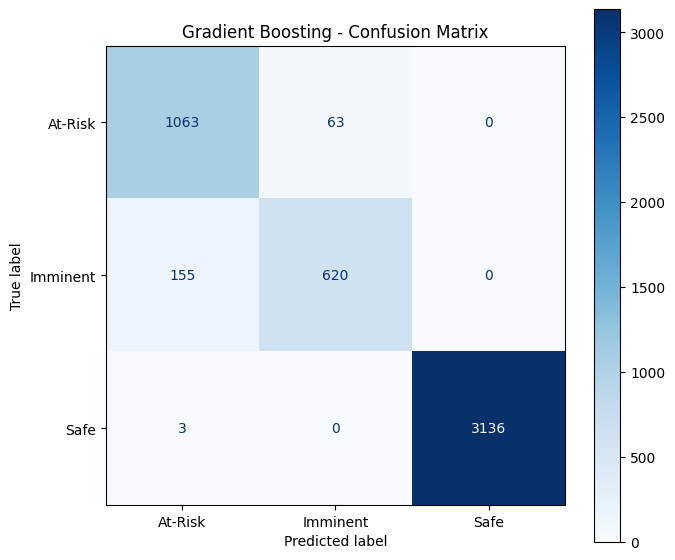

In [86]:
#Create the Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    gb_pred,
    labels=["At-Risk", "Imminent", "Safe"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["At-Risk", "Imminent", "Safe"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("Gradient Boosting - Confusion Matrix")
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [87]:
#Feature Importance
# Get transformed feature names
feature_names = gradient_boosting_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get Gradient Boosting feature importance
importances = gradient_boosting_model.named_steps[
    "model"
].feature_importances_

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15
feature_importance_df.head(15)

,Feature,Importance
6,num__days_of_cover,0.423040
15,num__reorder_gap,0.283559
16,num__days_of_cover_ratio,0.242733
10,num__supplier_reliability_clean,0.019432
9,num__lead_time_variance_days,0.005136
49,cat__reorder_placed_N,0.003886
3,num__closing_stock,0.003876
50,cat__reorder_placed_Y,0.003536
4,num__reorder_point,0.003327
0,num__opening_stock,0.002233


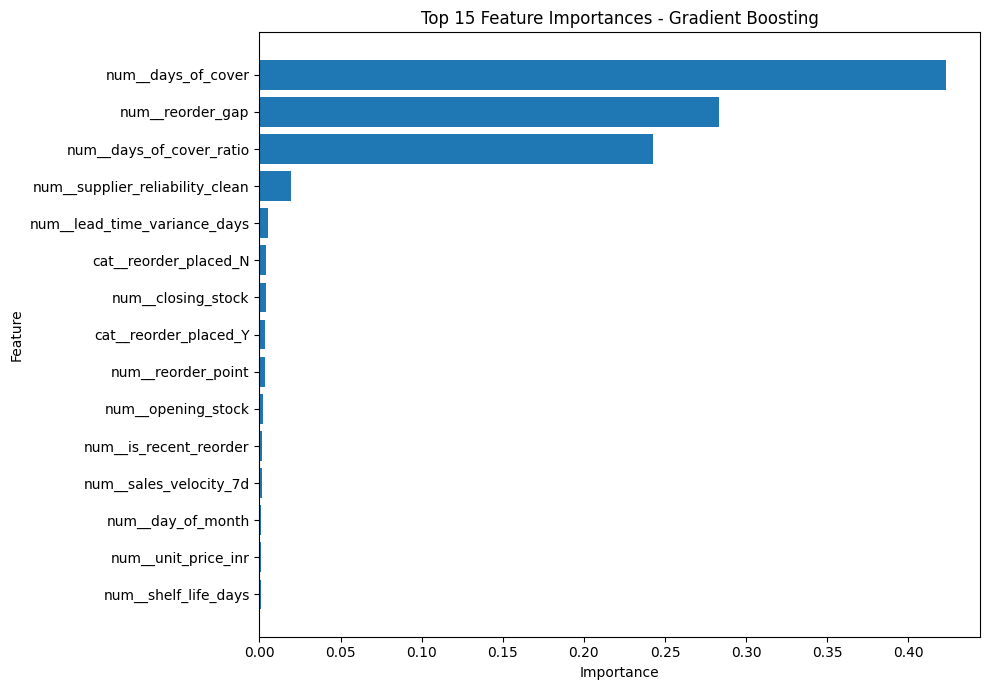

In [88]:
top_features = feature_importance_df.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [91]:
#final model comparison table
# Majority class baseline
majority_class = y_train.value_counts().idxmax()

majority_pred = pd.Series(
    majority_class,
    index=y_test.index
)

print("Majority Class:", majority_class)
print("Baseline Accuracy:", accuracy_score(y_test, majority_pred))
print(
    "Baseline Imminent Recall:",
    recall_score(
        y_test,
        majority_pred,
        labels=["Imminent"],
        average="macro",
        zero_division=0
    )
)

Majority Class: Safe
Baseline Accuracy: 0.6228174603174603
Baseline Imminent Recall: 0.0


In [92]:
from sklearn.metrics import precision_score, f1_score

model_comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, majority_pred),
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, majority_pred),
        balanced_accuracy_score(y_test, logistic_pred),
        balanced_accuracy_score(y_test, rf_pred),
        balanced_accuracy_score(y_test, gb_pred)
    ],
    "Imminent Recall": [
        0.0,
        recall_score(y_test, logistic_pred, labels=["Imminent"], average="macro"),
        recall_score(y_test, rf_pred, labels=["Imminent"], average="macro"),
        recall_score(y_test, gb_pred, labels=["Imminent"], average="macro")
    ],
    "Imminent Precision": [
        0.0,
        precision_score(y_test, logistic_pred, labels=["Imminent"], average="macro", zero_division=0),
        precision_score(y_test, rf_pred, labels=["Imminent"], average="macro", zero_division=0),
        precision_score(y_test, gb_pred, labels=["Imminent"], average="macro", zero_division=0)
    ],
    "Imminent F1": [
        0.0,
        f1_score(y_test, logistic_pred, labels=["Imminent"], average="macro"),
        f1_score(y_test, rf_pred, labels=["Imminent"], average="macro"),
        f1_score(y_test, gb_pred, labels=["Imminent"], average="macro")
    ]
})

model_comparison



,Model,Accuracy,Balanced Accuracy,Imminent Recall,Imminent Precision,Imminent F1
0,Majority Baseline,0.622817,0.333333,0.000000,0.000000,0.000000
1,Logistic Regression,0.893452,0.841510,0.984516,0.622349,0.762619
2,Random Forest,0.941270,0.884766,0.725161,0.879499,0.794908
3,Gradient Boosting,0.956151,0.914365,0.800000,0.907760,0.850480


Confusion Matrix:
[[1063   63    0]
 [ 155  620    0]
 [   3    0 3136]]


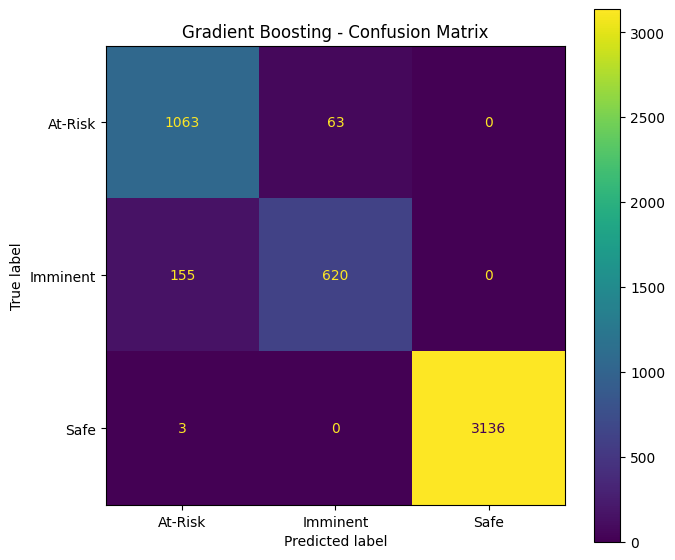

In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    gb_pred,
    labels=["At-Risk", "Imminent", "Safe"]
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["At-Risk", "Imminent", "Safe"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")

plt.title("Gradient Boosting - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

===== BUSINESS INSIGHTS =====

1. Imminent Stockout Risk:
is_festival_week
N     9.511633
Y    23.309179
Name: stockout_risk, dtype: float64

2. Perishable vs Non-Perishable:
is_perishable
N     9.298246
Y    12.765152
Name: stockout_risk, dtype: float64

3. Supplier Reliability:
reliability_group
Low     13.074495
Mid      3.263889
High     3.819444
Name: stockout_risk, dtype: float64

===== TOP 15 FEATURES =====
                            Feature  Importance
6                num__days_of_cover    0.423040
15                 num__reorder_gap    0.283559
16         num__days_of_cover_ratio    0.242733
10  num__supplier_reliability_clean    0.019432
9      num__lead_time_variance_days    0.005136
49            cat__reorder_placed_N    0.003886
3                num__closing_stock    0.003876
50            cat__reorder_placed_Y    0.003536
4                num__reorder_point    0.003327
0                num__opening_stock    0.002233
17           num__is_recent_reorder    0.001590
5     

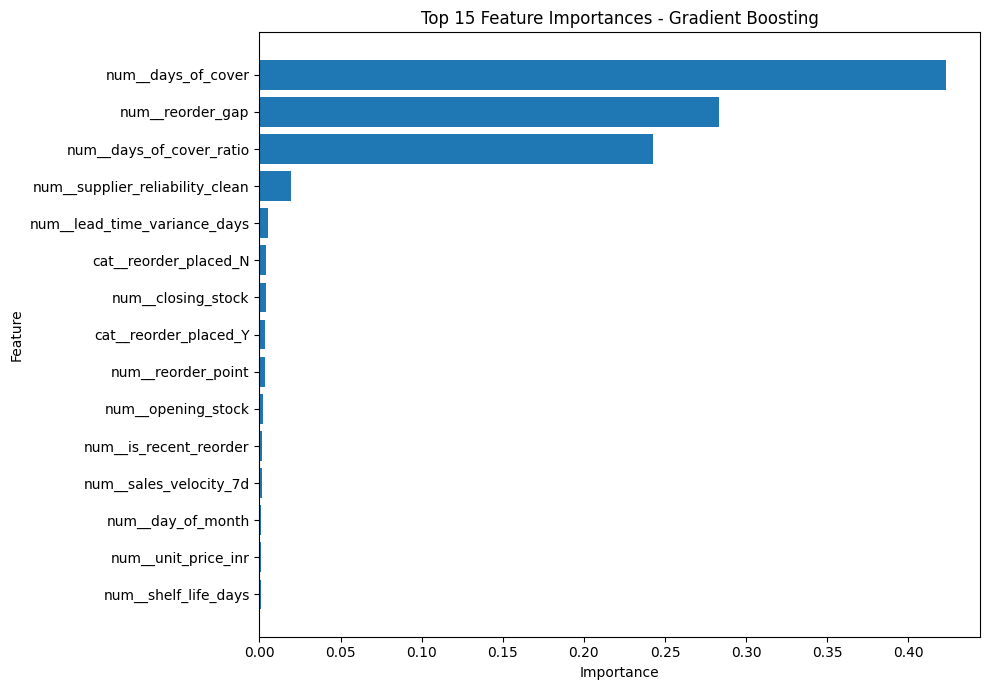

In [94]:
# ============================================
# FINAL BUSINESS ANALYSIS
# ============================================

print("===== BUSINESS INSIGHTS =====")

# 1. Festival vs non-festival
festival_summary = (
    df.groupby("is_festival_week")["stockout_risk"]
      .apply(lambda x: (x == "Imminent").mean() * 100)
)

print("\n1. Imminent Stockout Risk:")
print(festival_summary)

# 2. Perishable vs non-perishable
perishable_summary = (
    df.groupby("is_perishable")["stockout_risk"]
      .apply(lambda x: (x == "Imminent").mean() * 100)
)

print("\n2. Perishable vs Non-Perishable:")
print(perishable_summary)

# 3. Supplier reliability groups
df["reliability_group"] = pd.cut(
    df["supplier_reliability_clean"],
    bins=[-float("inf"), 0.75, 0.85, float("inf")],
    labels=["Low", "Mid", "High"]
)

reliability_summary = (
    df.groupby("reliability_group", observed=False)["stockout_risk"]
      .apply(lambda x: (x == "Imminent").mean() * 100)
)

print("\n3. Supplier Reliability:")
print(reliability_summary)


# ============================================
# FEATURE IMPORTANCE - GRADIENT BOOSTING
# ============================================

feature_names = gradient_boosting_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = gradient_boosting_model.named_steps[
    "model"
].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
)

print("\n===== TOP 15 FEATURES =====")
print(feature_importance_df.head(15))

# Plot
top_features = feature_importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.tight_layout()
plt.show()

Models saved successfully.


<Figure size 700x600 with 0 Axes>

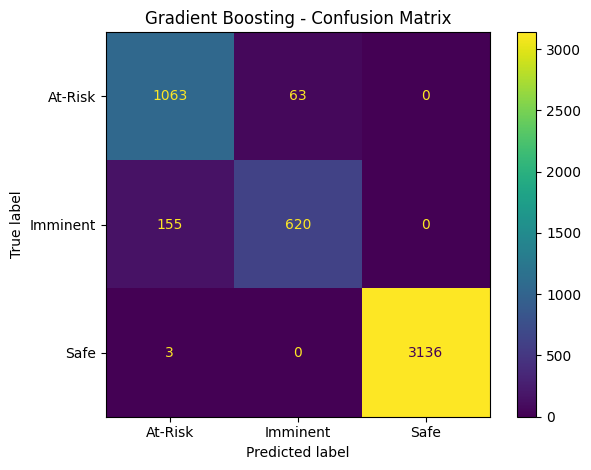

Confusion matrix saved.


In [95]:
import os
import joblib

# Create project output folders
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Save final recall-focused model
joblib.dump(
    logistic_model,
    "models/quickcart_stockout_final_model.pkl"
)

# Save Gradient Boosting comparison model
joblib.dump(
    gradient_boosting_model,
    "models/quickcart_gradient_boosting_model.pkl"
)

print("Models saved successfully.")

# Save confusion matrix figure
plt.figure(figsize=(7, 6))

cm = confusion_matrix(
    y_test,
    gb_pred,
    labels=["At-Risk", "Imminent", "Safe"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["At-Risk", "Imminent", "Safe"]
)

disp.plot(values_format="d")
plt.title("Gradient Boosting - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "outputs/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved.")

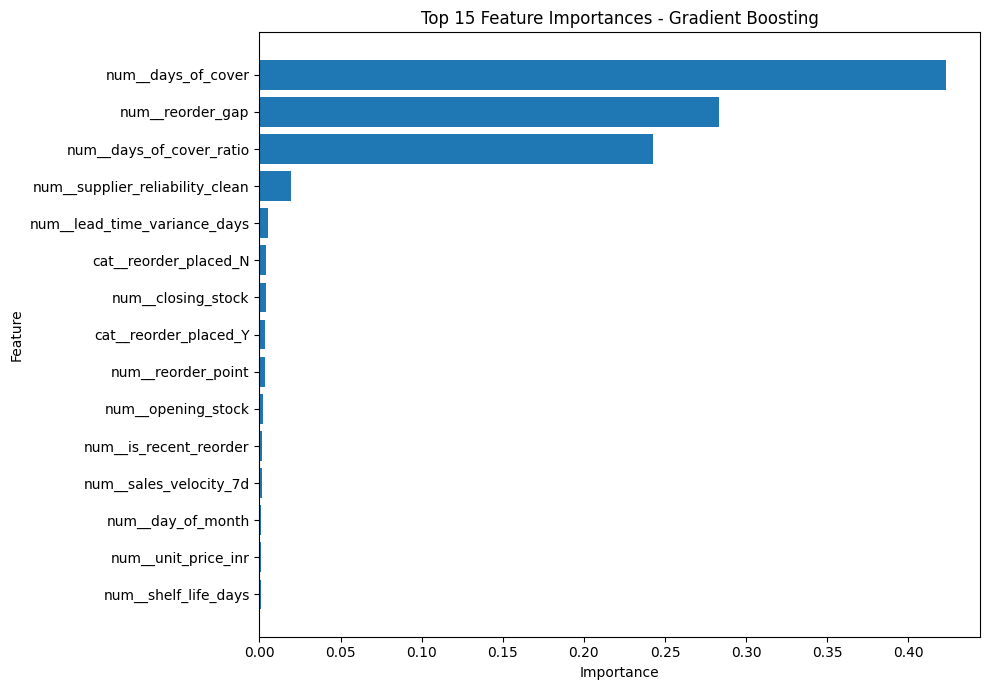


===== PROJECT OUTPUTS CREATED =====
outputs/model_comparison.csv
outputs/feature_importance.csv
outputs/confusion_matrix.png
outputs/feature_importance.png
models/quickcart_stockout_final_model.pkl
models/quickcart_gradient_boosting_model.pkl


In [96]:
# ============================================
# SAVE FINAL PROJECT OUTPUTS
# ============================================

# Save model comparison
model_comparison.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

# Save feature importance
feature_importance_df.to_csv(
    "outputs/feature_importance.csv",
    index=False
)

# Save top 15 feature importance chart
plt.figure(figsize=(10, 7))

top_features = feature_importance_df.head(15).sort_values(
    "Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.tight_layout()

plt.savefig(
    "outputs/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n===== PROJECT OUTPUTS CREATED =====")
print("outputs/model_comparison.csv")
print("outputs/feature_importance.csv")
print("outputs/confusion_matrix.png")
print("outputs/feature_importance.png")
print("models/quickcart_stockout_final_model.pkl")
print("models/quickcart_gradient_boosting_model.pkl")

Logistic Regression achieved the highest recall for the Imminent class (98.45%), making it the recall-focused model for the stockout prevention objective. Gradient Boosting achieved the highest overall accuracy (95.62%), balanced accuracy (91.44%), precision (90.78%), and F1-score (85.05%), making it a strong overall-performance model.